In [1]:
# if necessary, install NeuralGCM and dependencies
# ! pip install -q -U neuralgcm dinosaur-dycore gcsfs

In [2]:
# %pip install -U "jax[cuda12]"==0.4.30 -i https://pypi.tuna.tsinghua.edu.cn/simple   
# 其他的版本会报错，这里是先装的0.4.35，不卸载，再装0.4.30

In [3]:
# q
# 需要先装cmake, git, poetry, 在python=3.10下运行

# Forecasting quick start

This notebook uses ERA5 data and pretrained NeuralGCM model to make a weather forecast.

The forecast is made in 3 steps:
1. Slice of ERA5 data is regridded to model resolution
2. NeuralGCM model state is initialized and rolled out
3. Predictions and reference trajectory are combined for visualization

By default the notebook uses intermediate deterministic NeuralGCM 1.4° model. Other available checkpoints include deterministic 0.7°, 2.8° and stochastic 1.4° NeuralGCM variations.

```{tip}
You can run this notebook yourself in [Google Colab](https://colab.research.google.com/github/google-research/neuralgcm/blob/main/docs/inference_demo.ipynb). We recommend using a GPU or TPU runtime due to high memory and compute requirements.
```

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
device_ids = [0]

import gcsfs
import jax
import numpy as np
import pickle
import xarray

from dinosaur import horizontal_interpolation
from dinosaur import spherical_harmonic
from dinosaur import xarray_utils


import neuralgcm

import pandas as pd



import matplotlib.pyplot as plt

print(jax.devices())
gcs = gcsfs.GCSFileSystem(token='anon')

[cuda(id=0)]


## Load a pre-trained NeuralGCM model

```{caution}
Trained model weights are licensed for non-commercial use, under the Creative Commons [Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/) license (CC BY-NC-SA 4.0).
```

Pre-trained model checkpoints from the NeuralGCM paper are [available for download](https://console.cloud.google.com/storage/browser/gresearch/neuralgcm/04_30_2024) on Google Cloud Storage:

- Deterministic models:(确定性模型)
    - `gs://gresearch/neuralgcm/04_30_2024/neural_gcm_dynamic_forcing_deterministic_0_7_deg.pkl`
    - `gs://gresearch/neuralgcm/04_30_2024/neural_gcm_dynamic_forcing_deterministic_1_4_deg.pkl`
    - `gs://gresearch/neuralgcm/04_30_2024/neural_gcm_dynamic_forcing_deterministic_2_8_deg.pkl`
- Stochastic models:(随机模型)
    - `gs://gresearch/neuralgcm/04_30_2024/neural_gcm_dynamic_forcing_stochastic_1_4_deg.pkl`



In [2]:
model_name = 'neuralgcm_04_30_2024_neural_gcm_dynamic_forcing_deterministic_1_4_deg.pkl'  #@param ['neural_gcm_dynamic_forcing_deterministic_0_7_deg.pkl', 'neural_gcm_dynamic_forcing_deterministic_1_4_deg.pkl', 'neural_gcm_dynamic_forcing_deterministic_2_8_deg.pkl', 'neural_gcm_dynamic_forcing_stochastic_1_4_deg.pkl'] {type: "string"}
                                                                                          # 1_4可用
# 载入模型权重
with open(f'/nfs/gpu_homes/gpu09/home/zhangjing/Code/NeuralGCM/pkl/{model_name}', 'rb') as f:
   ckpt = pickle.load(f)

In [3]:
model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)  # 实例化NeuralGCM模型

# 如果需要同时获取物理核心结果和修正后结果，创建一个启用该功能的模型实例
# 这会在解码器中同时保存物理核心结果（不加深度学习修正）
model_with_physics = model.with_physics_core_output(enable=True)


print("模型分辨率为: ", 360/model.data_coords.horizontal.longitude_nodes)  # 360° 被 256 份均分，每格 360° / 256 ≈ 1.40625°

模型分辨率为:  1.40625


## Load ERA5 data from GCP/Zarr

See {doc}`datasets` for details.

Select out a few days of data:

数据准备-使用本地数据ERA5
使用本地数据驱动NGCM需要进行一些预处理，包括变量名的规范化、变量选取、插值与缺失值填补。

变量名规范化部分官方使用gcsfs中的get_mapper函数进行处理，但我初次测试时这个函数屡屡报错，因为懒得调试愤而使用以下dict手动对变量名进行调整，使其匹配官方要求。

注意：如果你的ERA5数据变量名与dict的key不同，需要手动检查替换（可以读入后先check一波），或者参考官方quick start，考虑使用gcsfs的那个get_mapper函数。

In [7]:
# 用来替换下载的Era5数据集的变量名的字典
var_dict = {
    'siconc':'sea_ice_cover', 
    'sst':'sea_surface_temperature',
    'u':'u_component_of_wind', 
    'v':'v_component_of_wind', 
    'z':'geopotential', 
    't':'temperature', 
    'q':'specific_humidity', 
    'ciwc':'specific_cloud_ice_water_content', 
    'clwc':'specific_cloud_liquid_water_content',
}

读取数据，我的surface与pressure数据分了两个文件下载，所以分别读取后merge。

又由于我下载ERA5的时候操作失误导致两个文件时次对不上（surface下多了），所以手动选取时段以保证对齐

In [ ]:
# 读取数据集
 #用一下date_range函数

# path = ['/nfs/gpu_homes/gpu09/home/zhangjing/Code/NeuralGCM/era5/surface_240709_240712.nc','/nfs/gpu_homes/gpu09/home/zhangjing/Code/NeuralGCM/era5/pressure_240709_240712.nc']

# era5_pressure = xarray.open_dataset(path[1]).sel(time=pd.date_range('2024-7-09 00:00:00','2024-7-12 23:00:00',freq='h'))
# era5_surface = xarray.open_dataset(path[0]).sel(time=pd.date_range('2024-7-09 00:00:00','2024-7-12 23:00:00',freq='h'))

检查一下数据。注意如果你的数据里有expver这个维度也要预先给它去掉，我们这份数据里是没有的

In [9]:
# era5_pressure

In [10]:
# era5_surface

In [11]:
# 自下载era5数据驱动neuralGCM
era5_surface_pth = '/home/zhangjing/Code/NeuralGCM/era5/era5_single_level_202001.nc'
era5_pressure_pth = '/home/zhangjing/Code/NeuralGCM/era5/era5_pressure_levels_202001.nc'

era5_pressure = xarray.open_dataset(era5_pressure_pth, decode_timedelta=False).sel(time=pd.date_range('2020-1-01 00:00:00','2020-1-20 23:00:00',freq='h'))
era5_surface = xarray.open_dataset(era5_surface_pth, decode_timedelta=False).sel(time=pd.date_range('2020-1-01 00:00:00','2020-1-20 23:00:00',freq='h'))
era5_pressure
era5_surface

<xarray.Dataset> Size: 751MB
Dimensions:     (time: 480, latitude: 181, longitude: 360)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 4kB 2020-01-01 ... 2020-01-20T23:00:00
    step        float64 8B ...
    surface     float64 8B ...
  * latitude    (latitude) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * longitude   (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
    valid_time  (time) datetime64[ns] 4kB ...
Data variables:
    siconc      (time, latitude, longitude) float32 125MB ...
    sst         (time, latitude, longitude) float32 125MB ...
    u10         (time, latitude, longitude) float32 125MB ...
    v10         (time, latitude, longitude) float32 125MB ...
    msl         (time, latitude, longitude) float32 125MB ...
    t2m         (time, latitude, longitude) float32 125MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-11-16T11:54 GRIB to CDM+CF via cfgrib-0.9.1...

拼接两部分输入数据，按模型要求重命名，提取模型所需变量

In [12]:
full_era5 = xarray.merge([era5_pressure,era5_surface]) #数据拼接

# 变量名规范化
full_era5 = full_era5.rename_vars(var_dict) 
# 保留模型所需变量
full_era5 = full_era5[model.input_variables + model.forcing_variables]

print("数据集的时间范围为", full_era5.time.min(), full_era5.time.max())
full_era5  # 处理前的数据集, 仅进行了变量重命名


数据集的时间范围为 <xarray.DataArray 'time' ()> Size: 8B
array('2020-01-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    number   int64 8B 0
    step     float64 8B 0.0
    surface  float64 8B ... <xarray.DataArray 'time' ()> Size: 8B
array('2020-01-20T23:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    number   int64 8B 0
    step     float64 8B 0.0
    surface  float64 8B ...


<xarray.Dataset> Size: 33GB
Dimensions:                              (time: 480, isobaricInhPa: 37,
                                          latitude: 181, longitude: 360)
Coordinates:
    number                               int64 8B 0
  * time                                 (time) datetime64[ns] 4kB 2020-01-01...
    step                                 float64 8B 0.0
  * isobaricInhPa                        (isobaricInhPa) float64 296B 1e+03 ....
  * latitude                             (latitude) float64 1kB 90.0 ... -90.0
  * longitude                            (longitude) float64 3kB -180.0 ... 1...
    valid_time                           (time) datetime64[ns] 4kB 2020-01-01...
    surface                              float64 8B ...
Data variables:
    geopotential                         (time, isobaricInhPa, latitude, longitude) float32 5GB ...
    specific_humidity                    (time, isobaricInhPa, latitude, longitude) float32 5GB ...
    temperature                          (time, isobaricInhPa, latitude, longitude) float32 5GB ...
    u_component_of_wind                  (time, isobaricInhPa, latitude, longitude) float32 5GB ...
    v_component_of_wind                  (time, isobaricInhPa, latitude, longitude) float32 5GB ...
    specific_cloud_ice_water_content     (time, isobaricInhPa, latitude, longitude) float32 5GB ...
    specific_cloud_liquid_water_content  (time, isobaricInhPa, latitude, longitude) float32 5GB ...
    sea_ice_cover                        (time, latitude, longitude) float32 125MB ...
    sea_surface_temperature              (time, latitude, longitude) float32 125MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-11-16T06:57 GRIB to CDM+CF via cfgrib-0.9.1...

regrid与fill¶
这部分照搬官方文档即可

In [13]:
# 构建regridder
from dinosaur import horizontal_interpolation
from dinosaur import spherical_harmonic
from dinosaur import xarray_utils

# 实例化球谐函数网格
full_era5_grid = spherical_harmonic.Grid(
    latitude_nodes=full_era5.sizes['latitude'],
    longitude_nodes=full_era5.sizes['longitude'],
    latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
    longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
)


# 网格结合高度层  Other available regridders include BilinearRegridder and NearestRegridder.
regridder = horizontal_interpolation.ConservativeRegridder(
    full_era5_grid, model.data_coords.horizontal, skipna=True
)

# 需要数据切片的话可以在这里进行，数据太大regrid会非常慢
sliced_era5 = full_era5
sliced_era5 = full_era5.isel(time=slice(0,100))  # 只取前24个时间步

# 将数据插值到网格上
regridded = xarray_utils.regrid(sliced_era5, regridder)
regridded

2025-12-02 12:58:29.833517: W external/xla/xla/service/gpu/nvptx_compiler.cc:763] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


<xarray.Dataset> Size: 3GB
Dimensions:                              (time: 100, isobaricInhPa: 37,
                                          longitude: 256, latitude: 128)
Coordinates:
    number                               int64 8B 0
  * time                                 (time) datetime64[ns] 800B 2020-01-0...
    step                                 float64 8B 0.0
  * isobaricInhPa                        (isobaricInhPa) float64 296B 1e+03 ....
    valid_time                           (time) datetime64[ns] 800B 2020-01-0...
    surface                              float64 8B ...
  * longitude                            (longitude) float64 2kB 0.0 ... 358.6
  * latitude                             (latitude) float64 1kB -88.93 ... 88.93
Data variables:
    geopotential                         (time, isobaricInhPa, longitude, latitude) float32 485MB ...
    specific_humidity                    (time, isobaricInhPa, longitude, latitude) float32 485MB ...
    temperature                          (time, isobaricInhPa, longitude, latitude) float32 485MB ...
    u_component_of_wind                  (time, isobaricInhPa, longitude, latitude) float32 485MB ...
    v_component_of_wind                  (time, isobaricInhPa, longitude, latitude) float32 485MB ...
    specific_cloud_ice_water_content     (time, isobaricInhPa, longitude, latitude) float32 485MB ...
    specific_cloud_liquid_water_content  (time, isobaricInhPa, longitude, latitude) float32 485MB ...
    sea_ice_cover                        (time, longitude, latitude) float32 13MB ...
    sea_surface_temperature              (time, longitude, latitude) float32 13MB ...

可视化检查regrid效果

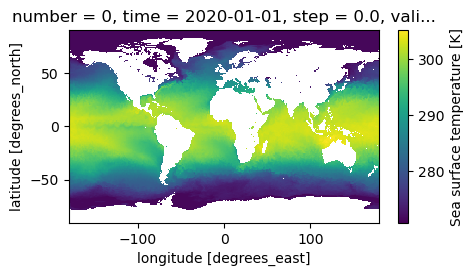

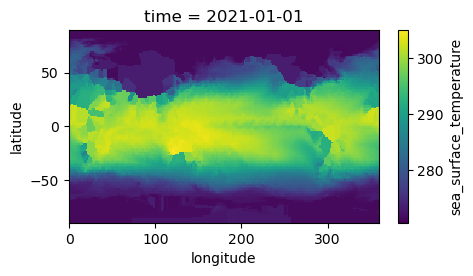

In [32]:
%matplotlib inline
# 展示插值前后的海温
sliced_era5.sea_surface_temperature.isel(time=0).plot(x='longitude', y='latitude', aspect=2, size=2.5);
regridded.sea_surface_temperature.isel(time=0).plot(x='longitude', y='latitude', aspect=2, size=2.5);

fillna并检查效果，这里也是照搬官方文档

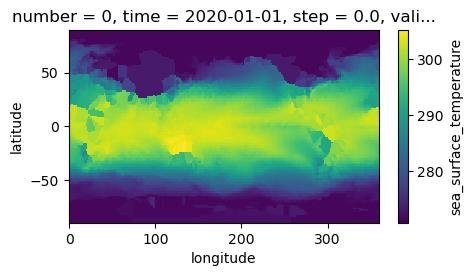

In [15]:
# 填补插值后数据中的NaN值并绘图
regridded_and_filled = xarray_utils.fill_nan_with_nearest(regridded)
regridded_and_filled.sea_surface_temperature.isel(time=0).plot(x='longitude', y='latitude', aspect=2, size=2.5)

In [16]:
regridded_and_filled

<xarray.Dataset> Size: 3GB
Dimensions:                              (time: 100, isobaricInhPa: 37,
                                          longitude: 256, latitude: 128)
Coordinates:
    number                               int64 8B 0
  * time                                 (time) datetime64[ns] 800B 2020-01-0...
    step                                 float64 8B 0.0
  * isobaricInhPa                        (isobaricInhPa) float64 296B 1e+03 ....
    valid_time                           (time) datetime64[ns] 800B 2020-01-0...
    surface                              float64 8B 0.0
  * longitude                            (longitude) float64 2kB 0.0 ... 358.6
  * latitude                             (latitude) float64 1kB -88.93 ... 88.93
Data variables:
    geopotential                         (time, isobaricInhPa, longitude, latitude) float32 485MB ...
    specific_humidity                    (time, isobaricInhPa, longitude, latitude) float32 485MB ...
    temperature                          (time, isobaricInhPa, longitude, latitude) float32 485MB ...
    u_component_of_wind                  (time, isobaricInhPa, longitude, latitude) float32 485MB ...
    v_component_of_wind                  (time, isobaricInhPa, longitude, latitude) float32 485MB ...
    specific_cloud_ice_water_content     (time, isobaricInhPa, longitude, latitude) float32 485MB ...
    specific_cloud_liquid_water_content  (time, isobaricInhPa, longitude, latitude) float32 485MB ...
    sea_ice_cover                        (time, longitude, latitude) float32 13MB ...
    sea_surface_temperature              (time, longitude, latitude) float32 13MB ...

至此数据已经ready to serve

In [4]:
# 直接读取regridded_and_filled后的数据集
regridded_pth = '/nfs/samba/数据聚变/气象数据/ERA5_Global_37Level_01Degree/Uncompressed_Regridded_and_Filled/2022/04/01/20220401.nc'

regridded_and_filled = xarray.open_dataset(regridded_pth, decode_timedelta=False).sel(time=pd.date_range('2022-04-01 00:00:00','2022-04-01 23:00:00',freq='h'))
regridded_and_filled

<xarray.Dataset> Size: 834MB
Dimensions:                              (time: 24, level: 37, longitude: 256,
                                          latitude: 128)
Coordinates:
  * time                                 (time) datetime64[ns] 192B 2022-04-0...
  * level                                (level) float64 296B 1.0 2.0 ... 1e+03
  * longitude                            (longitude) float64 2kB 0.0 ... 358.6
  * latitude                             (latitude) float64 1kB -88.93 ... 88.93
Data variables: (12/13)
    geopotential                         (time, level, longitude, latitude) float32 116MB ...
    specific_cloud_ice_water_content     (time, level, longitude, latitude) float32 116MB ...
    specific_cloud_liquid_water_content  (time, level, longitude, latitude) float32 116MB ...
    specific_humidity                    (time, level, longitude, latitude) float32 116MB ...
    temperature                          (time, level, longitude, latitude) float32 116MB ...
    u_component_of_wind                  (time, level, longitude, latitude) float32 116MB ...
    ...                                   ...
    10m_u_component_of_wind              (time, longitude, latitude) float32 3MB ...
    10m_v_component_of_wind              (time, longitude, latitude) float32 3MB ...
    2m_temperature                       (time, longitude, latitude) float32 3MB ...
    mean_sea_level_pressure              (time, longitude, latitude) float32 3MB ...
    sea_surface_temperature              (time, longitude, latitude) float32 3MB ...
    sea_ice_cover                        (time, longitude, latitude) float32 3MB ...

## 开始预测
这里可以修改的地方有：

inner_steps: 输出时间间隔，设为1=逐小时输出（原为24
outer_steps：输出总时次，设为2*24以输出共48小时（原为4x24
inputs阶段的.isel(time=？)：输入用的时次，这里输入第一个时次，后面的时次用于对比预报效果，这里我没改
其他我没有改动，可以参考Deep-dive into trained models - NeuralGCM documentation进行进一步调整

In [5]:
import numpy as np

inner_steps = 1  # save model outputs once every 24 hours
outer_steps = 1 * 20 // inner_steps  # 输出的总时间步数, n * 24 // inner_steps即往后预报多少天 total of 4 days, 原版为 4 * 24 // inner_steps
timedelta = np.timedelta64(1, 'h') * inner_steps    # 设定dt为一小时
times = (np.arange(outer_steps) * inner_steps)  # time axis in hours


# 训练时输入数据从这里开始处理

In [6]:
# Dataloader需要给出regridded_and_filled即可开始推理, 其为xarray.Dataset格式数据
# encoder前的数据处理.  initialize model state
# 使用模型的处理函数将
# 1. 插值填充后的部分数据 转换为 模型输入格式
# if "isobaricInhPa" in regridded_and_filled.coords:
#     regridded_and_filled = regridded_and_filled.rename({"isobaricInhPa": "level"})
# regridded_and_filled = regridded_and_filled.isel(level=slice(None, None, -1))

inputs = model.inputs_from_xarray(regridded_and_filled.isel(time=0))

# 2. 插值填充后的部分数据 转换为 模型强迫项格式
input_forcings = model.forcings_from_xarray(regridded_and_filled.isel(time=0))

# 随机场
rng_key = jax.random.key(42)  # optional for deterministic models


2025-12-06 12:22:50.181124: W external/xla/xla/service/gpu/nvptx_compiler.cc:763] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [7]:
# 这里说明input格式为字典, 这里使用操作字典的函数, 显示该字典的所有的键
inputs.keys()

dict_keys(['geopotential', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind', 'specific_cloud_ice_water_content', 'specific_cloud_liquid_water_content', 'sim_time'])

In [8]:
initial_state = model.encode(inputs, input_forcings, rng_key)

In [9]:
initial_state

ModelState(state=StateWithTime(vorticity=Array([[[ 3.0746125e-03, -3.0191243e-02,  1.5853690e-03, ...,
          1.4129471e-09,  3.9553929e-09,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00, -1.2945059e-03, -7.4325725e-03, ...,
          2.8698768e-09,  3.4255452e-09,  0.0000000e+00],
        ...,
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          3.4435252e-09, -3.9219041e-09,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00, -7.4160916e-10, -0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00, -1.3203981e-09, -0.0000000e+00]],

       [[-6.0324604e-03, -1.9823466e-03,  4.4372575e-03, ...,
          2.9924305e-10,  1.9770308e-09,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  

In [10]:
# use persistence for forcing variables (SST and sea ice cover)
all_forcings = model.forcings_from_xarray(regridded_and_filled.head(time=1))


In [11]:
# 开始预测
# final_state, predictions = model.unroll(
#     initial_state,
#     all_forcings,
#     steps=outer_steps,
#     timedelta=timedelta,
#     start_with_input=True,
# )


# predictions_ds = model.data_to_xarray(predictions, times=times)
# 使用启用物理核心输出的模型进行预测
final_state_with_physics, predictions_with_physics = model_with_physics.unroll(
    initial_state,
    all_forcings,
    steps=outer_steps,
    timedelta=timedelta,
    start_with_input=True,
)

# 使用 data_to_xarray_with_physics 方法分离物理核心结果和完整预测结果
# predictions_ds: 物理核心 + 深度学习修正
# predictions_phy_ds: 仅物理核心（不包含深度学习修正）
predictions_ds, predictions_phy_ds = model_with_physics.data_to_xarray_with_physics(
    predictions_with_physics, times=times
)

## 效果对比
拼合ERA5与模型输出
data_inner_steps应该是用于确认数据时间分辨率的，文档内没找到具体说明，保险起见设为与预报阶段的inner_steps一致

In [13]:
data_inner_steps = 1
# 从完全相同的同一时间段中选择 ERA5 目标数据
target_trajectory = model.inputs_from_xarray(
    regridded_and_filled
    .thin(time=(inner_steps // data_inner_steps))
    .isel(time=slice(outer_steps))
)
target_data_ds = model.data_to_xarray(target_trajectory, times=times)   # 将真实值转换为xarray.Dataset格式

combined_ds = xarray.concat([target_data_ds, predictions_ds], 'model')  # 新建维度'model'并在上边拼接真实值与预测结果, 用于区分ERA5和NeuralGCM的预测结果
combined_ds.coords['model'] = ['ERA5', 'NeuralGCM']

combined_ds_with_physics = xarray.concat(
    [target_data_ds, predictions_phy_ds, predictions_ds], 
    'model'
)
combined_ds_with_physics.coords['model'] = ['ERA5', 'Physics_Core', 'NeuralGCM']

In [14]:
# combined_ds
combined_ds_with_physics

<xarray.Dataset> Size: 2GB
Dimensions:                              (model: 3, time: 20, level: 37,
                                          longitude: 256, latitude: 128)
Coordinates:
  * longitude                            (longitude) float64 2kB 0.0 ... 358.6
  * latitude                             (latitude) float64 1kB -88.93 ... 88.93
  * level                                (level) int64 296B 1 2 3 ... 975 1000
  * time                                 (time) int64 160B 0 1 2 3 ... 17 18 19
  * model                                (model) <U12 144B 'ERA5' ... 'Neural...
Data variables:
    v_component_of_wind                  (model, time, level, longitude, latitude) float32 291MB ...
    specific_humidity                    (model, time, level, longitude, latitude) float32 291MB ...
    geopotential                         (model, time, level, longitude, latitude) float32 291MB ...
    u_component_of_wind                  (model, time, level, longitude, latitude) float32 291MB ...
    sim_time                             (model, time) float64 480B 1.99e+05 ...
    specific_cloud_ice_water_content     (model, time, level, longitude, latitude) float32 291MB ...
    temperature                          (model, time, level, longitude, latitude) float32 291MB ...
    specific_cloud_liquid_water_content  (model, time, level, longitude, latitude) float32 291MB ...
Attributes:
    longitude_wavenumbers:     128
    total_wavenumbers:         129
    longitude_nodes:           256
    latitude_nodes:            128
    latitude_spacing:          gauss
    longitude_offset:          0.0
    radius:                    1.0
    spherical_harmonics_impl:  RealSphericalHarmonicsWithZeroImag
    spmd_mesh:                 
    centers:                   [1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100, 125, ...
    horizontal_grid_type:      Grid
    vertical_grid_type:        PressureCoordinates

## 可视化检查
combined_ds可以保存成nc文件进行检查

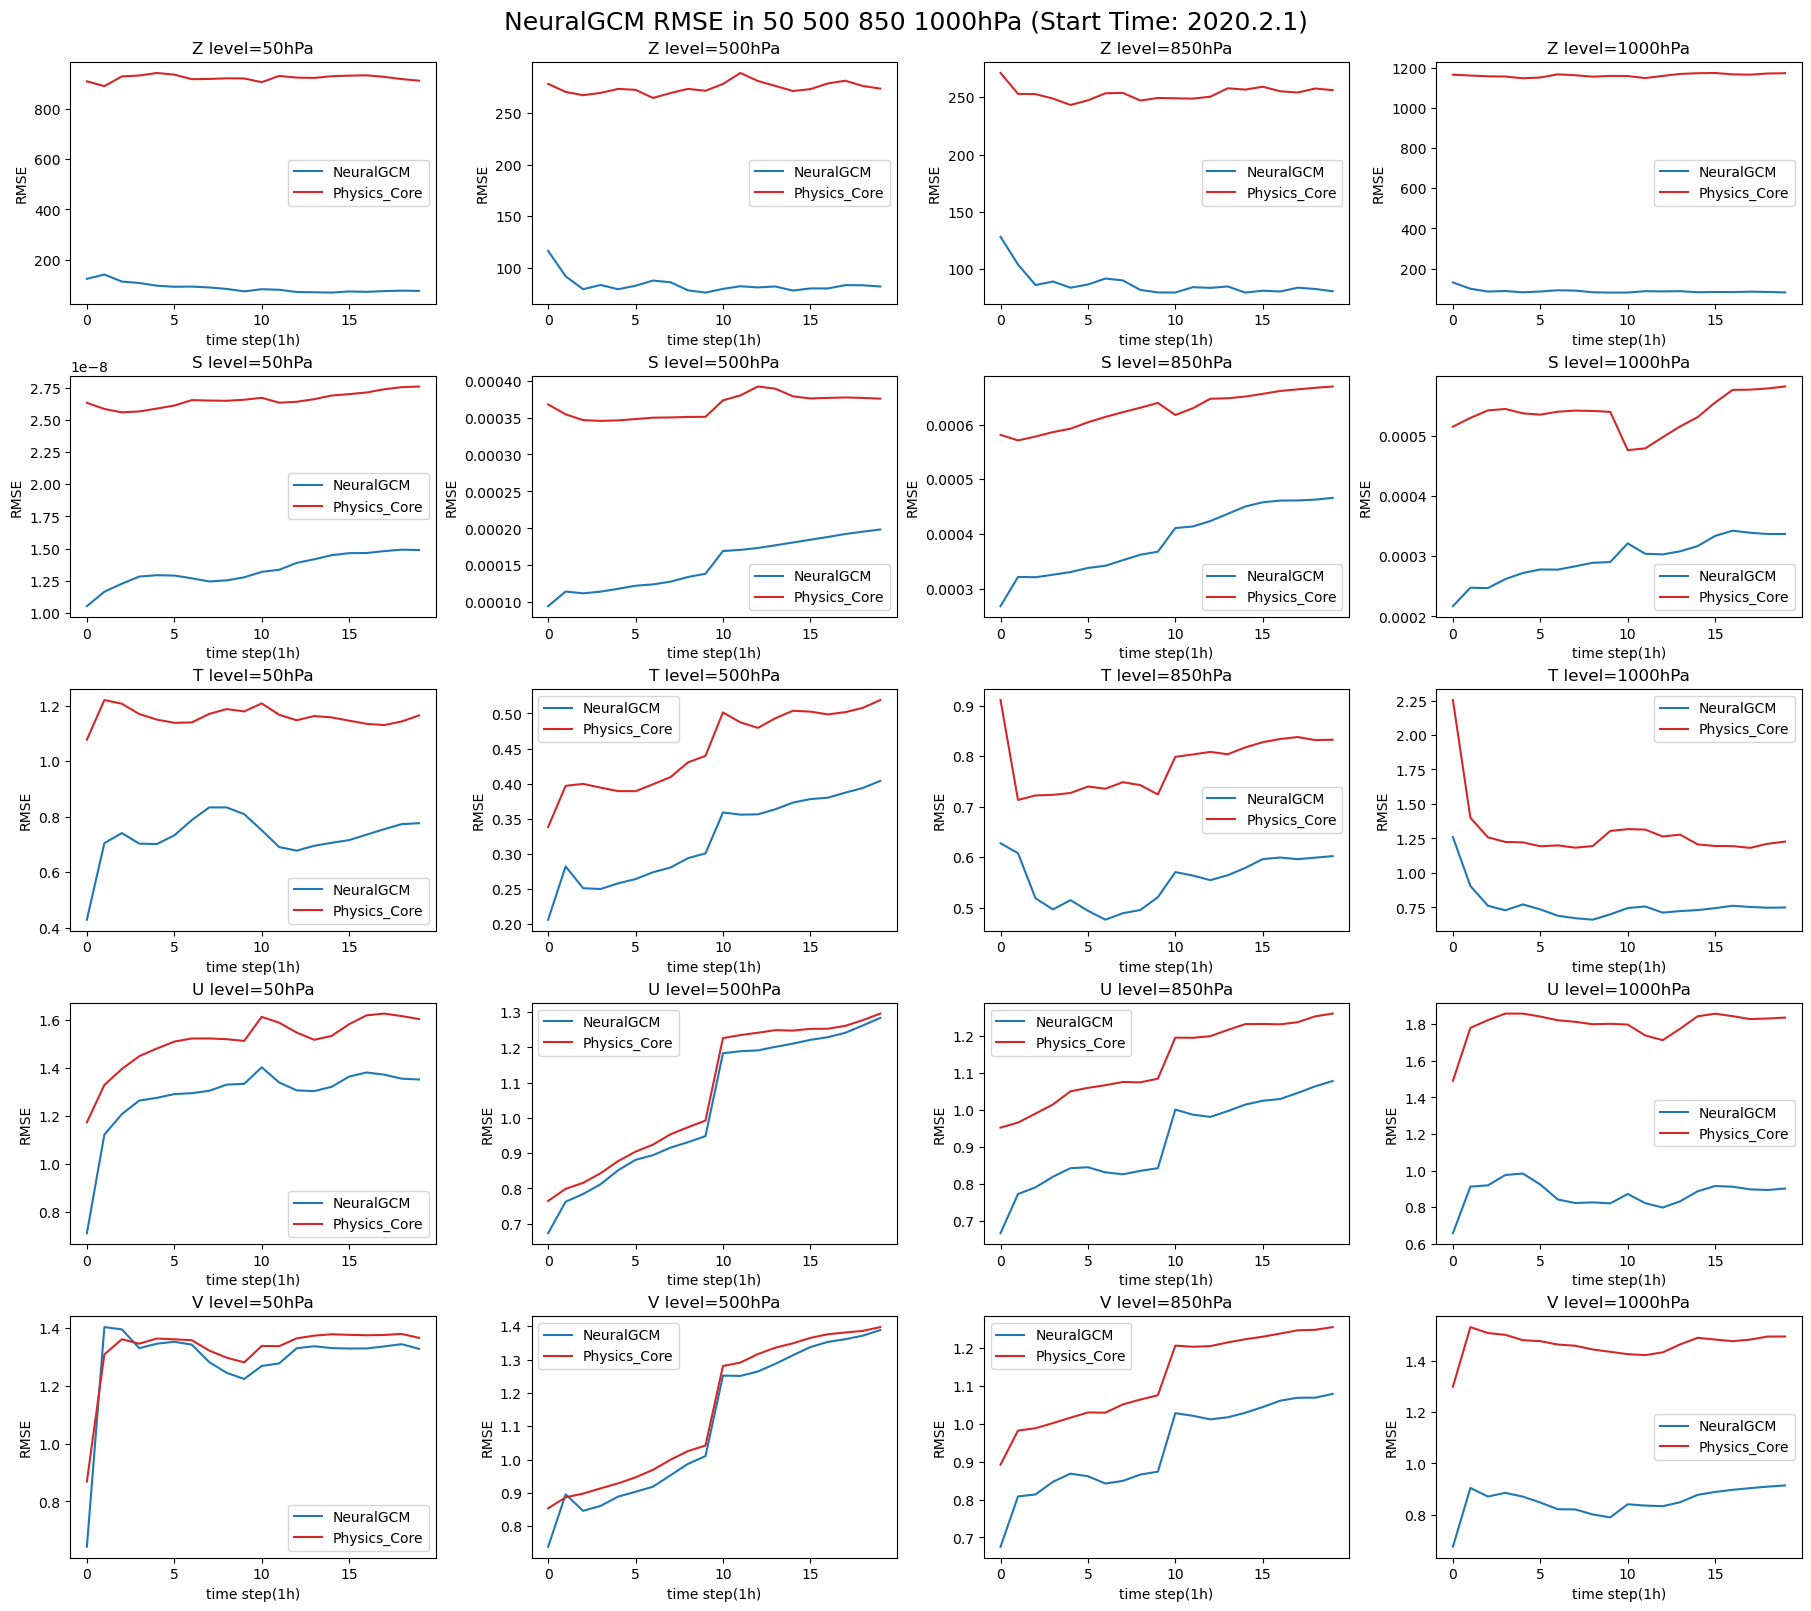

In [15]:
# 选择4个高度层, 绘制RMSE随时间变化曲线
target = combined_ds_with_physics.sel(model="ERA5")
baseline = combined_ds_with_physics.sel(model="NeuralGCM")
baseline_phy = combined_ds_with_physics.sel(model="Physics_Core")

diff = target - baseline
diff_phy = target - baseline_phy

var_map = {
    "z": "geopotential",
    "s": "specific_humidity",
    "t": "temperature",
    "u": "u_component_of_wind",
    "v": "v_component_of_wind",
}
levels_to_plot = [50, 500, 850, 1000]

fig, axes = plt.subplots(
    nrows=len(var_map),
    ncols=len(levels_to_plot),
    figsize=(18, 16),
    sharex=False,
    constrained_layout=True,
)

for row_idx, (label, var_name) in enumerate(var_map.items()):
    da_full = diff[var_name]
    da_full_phy = diff_phy[var_name]

    for col_idx, level_value in enumerate(levels_to_plot):
        da = da_full.sel(level=level_value, method="nearest")
        da_phy = da_full_phy.sel(level=level_value, method="nearest")

        reduce_dims = [d for d in da.dims if d != "time"]
        reduce_dims_phy = [d for d in da_phy.dims if d != "time"]

        mse = (da**2).mean(dim=reduce_dims, skipna=True)
        mse_phy = (da_phy**2).mean(dim=reduce_dims_phy, skipna=True)

        rmse = np.sqrt(mse)
        rmse_phy = np.sqrt(mse_phy)

        ax = axes[row_idx, col_idx]
        rmse.plot(ax=ax, color="tab:blue", label="NeuralGCM")
        rmse_phy.plot(ax=ax, color="tab:red", label="Physics_Core")

        ax.set_title(f"{label.upper()} level={level_value}hPa")
        ax.set_xlabel("time step(1h)")
        ax.set_ylabel("RMSE")
        ax.legend()

plt.suptitle("NeuralGCM RMSE in 50 500 850 1000hPa (Start Time: 2020.2.1)", fontsize=18)
plt.show()

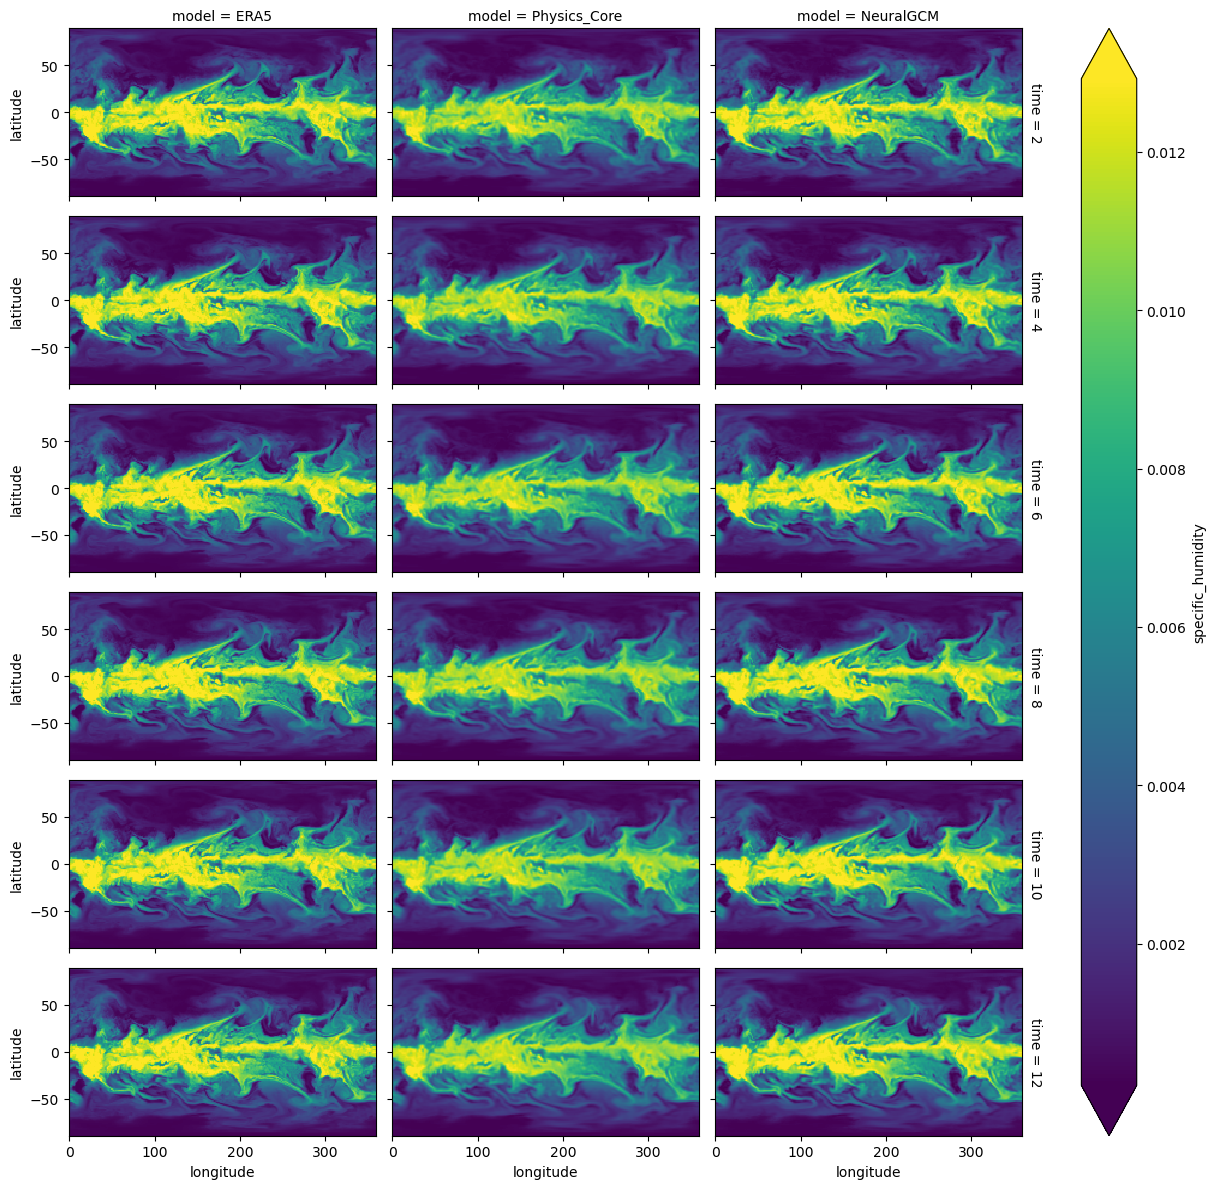

In [25]:
# Visualize ERA5 vs NeuralGCM trajectories
# combined_ds.specific_humidity.sel(level=850,time=slice(2,12+1,2)).plot(
#     x='longitude', y='latitude', row='time', col='model', robust=True, aspect=2, size=2
# );

combined_ds_with_physics.specific_humidity.sel(level=850,time=slice(2,12+1,2)).plot(
    x='longitude', y='latitude', row='time', col='model', robust=True, aspect=2, size=2
);

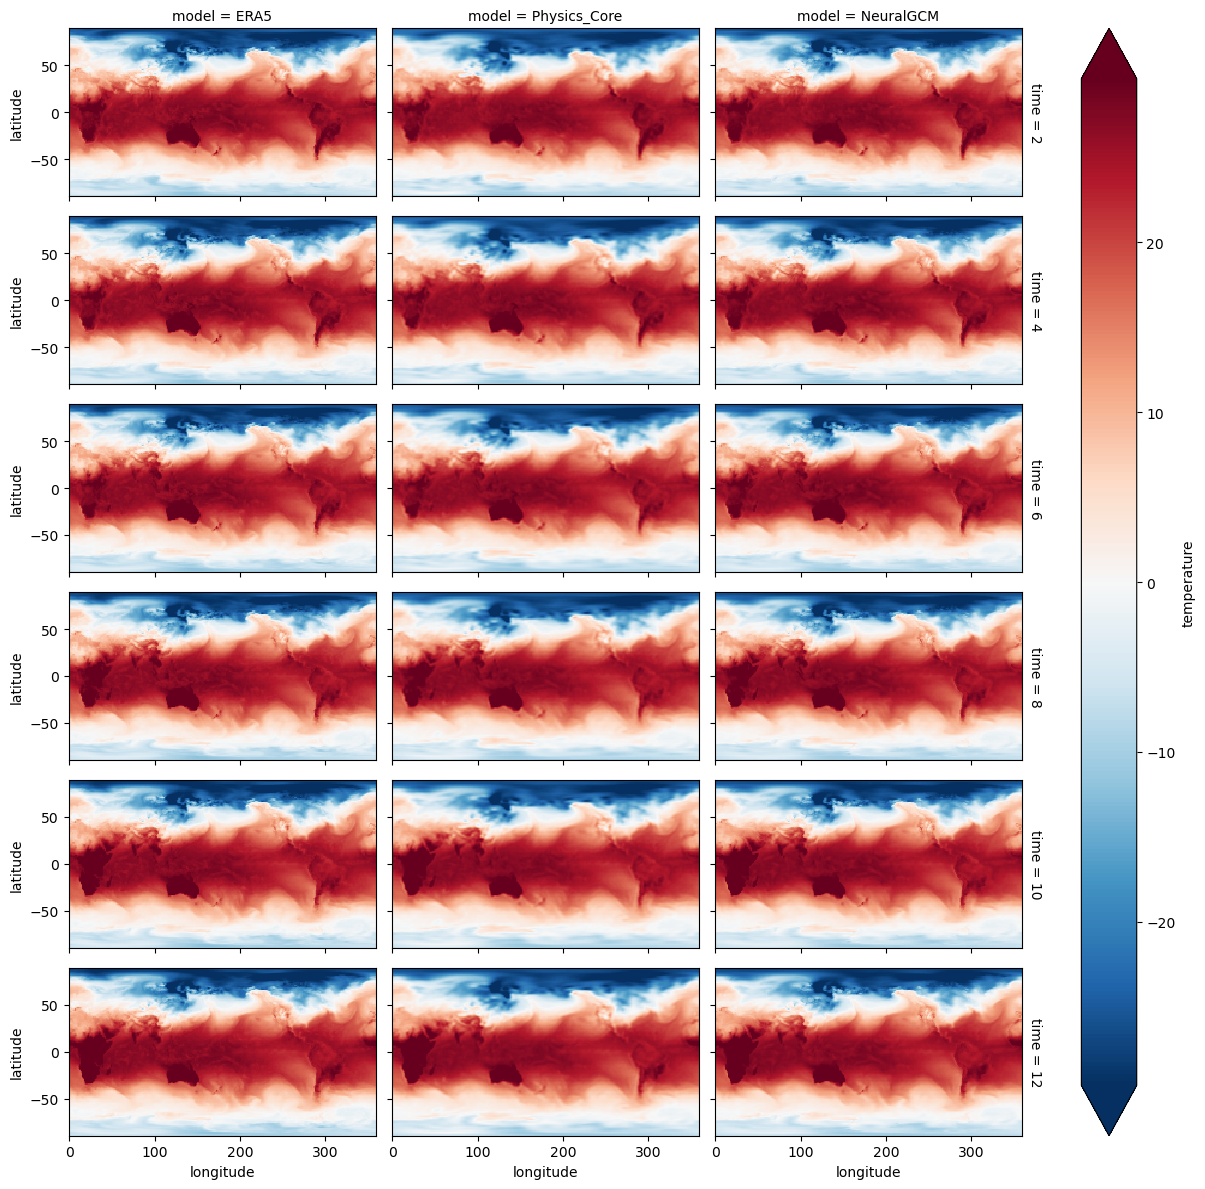

In [28]:
# test_temperature = combined_ds.temperature-273.15

# test_temperature.sel(level=1000,time=slice(2,12+1,2)).plot(
#     x='longitude', y='latitude', row='time', col='model', robust=True, aspect=2, size=2
# );

test_temperature_with_physics = combined_ds_with_physics.temperature-273.15

test_temperature_with_physics.sel(level=1000,time=slice(2,12+1,2)).plot(
    x='longitude', y='latitude', row='time', col='model', robust=True, aspect=2, size=2
);  


In [29]:
test_t1000 = test_temperature.sel(level=1000,time=slice(1,4+1,1))
test_t_diff = test_t1000.sel(model='NeuralGCM')-test_t1000.sel(model='ERA5')
test_t_diff.plot(
    x='longitude', y='latitude', row='time', robust=True, aspect=2, size=3
);

NameError: name 'test_temperature' is not defined

In [ ]:
#era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
#full_era5 = xarray.open_zarr(gcs.get_mapper(era5_path), chunks=None)

In [ ]:
demo_start_time = '2024-07-14'
demo_end_time = '2024-02-18'
data_inner_steps = 24  # process every 24th hour

In [ ]:
sliced_era5 = (
    full_era5
    [model.input_variables + model.forcing_variables]
    .pipe(
        xarray_utils.selective_temporal_shift,
        variables=model.forcing_variables,
        time_shift='24 hours',
    )
    .sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
    .compute()
)

print('sliced_era5 time size:', sliced_era5.sizes['time'])
print('sliced_era5 time values:', sliced_era5.time.values)


sliced_era5 time size: 0
sliced_era5 time values: []
